In [3]:
import scanpy as sc

In [110]:
import scanpy as sc
import pandas as pd

# 데이터 불러오기
adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/GC/Final_Macrophage.h5ad")

# 필터링 (선택적으로 기준 조정)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 미토콘드리아 유전자 비율 계산 (사람일 경우 ‘MT-’ prefix)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Normalize, log transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Highly variable genes (HVGs) 선택 (pySCENIC 입력으로 사용)
sc.pp.highly_variable_genes(adata, n_top_genes=5000)
adata = adata[:, adata.var['highly_variable']]



In [52]:
adata = adata[(adata.obs['final'] == 'M1') | (adata.obs['final'] == 'M2')]
adata.obs['final'].value_counts()
expr_matrix = adata.X  # 전치해서 세포 x 유전자 행렬로 만듭니다.

# 전치된 행렬을 pandas DataFrame으로 변환 (이미 numpy.ndarray 형식이므로 toarray() 불필요)
expr_df = pd.DataFrame(expr_matrix, index=adata.obs_names, columns=adata.var_names)

# TSV 파일로 저장 (제대로 구분된 형식)
expr_df.to_csv('/home/Data_Drive_8TB/kykim/GC/pyScenic/M1M2expr_matrix.tsv', sep='\t')

In [274]:
import pandas as pd

# regulons.csv 경로 지정
regulon_path = "/home/Data_Drive_8TB/kykim/GC/pyScenic/M1_only_output/regulons_final.csv"

# 파일 읽기
df_regulons = pd.read_csv(regulon_path)

# 확인
df_regulons

,TF,MotifID,AUC,NES,MotifSimilarityQvalue,OrthologousIdentity,Annotation,Context,TargetGenes,RankAtMax,IL10,IL4,KLF4,IRF4,SOCS1,X,CD44,CXCR4
0,IRF1,homer__AGTTTCAGTTTC_ISRE,0.073676,3.993689,0.000001,1.000000,gene is annotated for similar motif cisbp__M63...,frozenset({'hg38__refseq-r80__500bp_up_and_100...,"[('MARCKSL1', 9.919885925547996), ('C11orf96',...",4378,1,1,1,1,0,4,0,1
1,IRF7,dbcorrdb__STAT2__ENCSR000FBC_1__m1,0.159678,8.886353,0.000000,1.000000,gene is annotated for similar motif transfac_p...,frozenset({'hg38__refseq-r80__500bp_up_and_100...,"[('KLF6', 7.19418463941239), ('NEAT1', 2.10157...",3878,1,1,1,0,0,3,0,1
2,FOS,transfac_pro__M08921,0.073775,4.067548,0.000000,1.000000,motif similar to taipale_cyt_meth__FOS_NRTGACG...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('NFKBIA', 14.128806059967772), ('INTS6', 6.1...",1862,1,1,1,0,0,3,0,0
3,ATF3,cisbp__M0326,0.063151,4.022227,0.000832,1.000000,motif similar to factorbook__CREB ('CREB'; q-v...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('NFKBIA', 45.02034212570174), ('INTS6', 3.90...",1111,1,1,1,0,0,3,0,0
4,JUN,homer__HTGCTGAGTCAT_Nrf2,0.060322,3.079577,0.000982,1.000000,gene is annotated for similar motif transfac_p...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('NFKBIA', 38.37812882508873), ('INTS6', 9.02...",1103,1,1,1,0,0,3,0,0
5,JUND,taipale_cyt_meth__CREB5_NRTGAYGTCAYN_eDBD,0.088803,4.670200,0.000000,1.000000,motif similar to taipale_cyt_meth__JUND_NRTGAC...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('CCND1', 3.9799875915216583), ('CD164L2', 2....",4359,0,0,1,1,0,2,1,1
6,SPIB,dbcorrdb__SPI1__ENCSR000BGQ_1__m1,0.075551,4.540009,0.000000,1.000000,motif similar to hocomoco__SPIB_HUMAN.H11MO.0....,frozenset({'hg38__refseq-r80__500bp_up_and_100...,"[('ALOX5AP', 0.5741055546365983), ('FCGR2B', 0...",1278,0,1,0,1,0,2,0,0
7,RUNX3,transfac_pro__M08865,0.069694,3.586305,0.000355,1.000000,gene is annotated for similar motif transfac_p...,frozenset({'hg38__refseq-r80__500bp_up_and_100...,"[('IHH', 0.0001159399720835), ('RXRA', 0.11470...",3747,0,0,1,1,0,2,0,1
8,E2F1,transfac_pro__M00918,0.221220,9.921019,0.000000,1.000000,gene is directly annotated,"frozenset({'top5perTarget', 'hg38__refseq-r80_...","[('CDCA2', 4.174876994667811), ('HMGB2', 9.174...",1122,0,0,0,0,0,0,0,0
9,TFDP1,transfac_public__M00050,0.143467,7.121861,0.000044,1.000000,motif similar to transfac_pro__M00738 ('V$E2F4...,frozenset({'hg38__refseq-r80__500bp_up_and_100...,"[('HELLS', 1.8922176496898304), ('MCM6', 7.720...",576,0,0,0,0,0,0,0,0


In [1]:
import matplotlib.pyplot as plt

# 강조할 TF 목록
highlight_tfs = {'IRF1','IRF7','FOS','ATF3','JUN','JUND','SPIB','RUNX3'
}


# NES 기준으로 정렬하고 순위 열 생성
df_sorted = df_regulons.sort_values(by='NES', ascending=False).reset_index(drop=True)

# 플롯
plt.figure(figsize=(4, 4))

# 파란색 점
plt.scatter(range(len(df_sorted)), df_sorted['NES'], color='blue', s=20)

# 강조할 TF에 대해서만 텍스트와 화살표 표시
for i, row in df_sorted.iterrows():
    tf = str(row['TF'])  # TF 이름을 'Annotation' 열에서 가져옵니다.
    if tf in highlight_tfs:
        # 화살표와 텍스트 추가
        plt.annotate(tf,
                     (i, row['NES']),
                     xytext=(0, 30),  # 텍스트를 위로 올리기 위한 오프셋
                     textcoords="offset points",
                     ha='center',
                     fontsize=5,
                     color='red',
                     arrowprops=dict(facecolor='red', arrowstyle='->', lw=2))  # 화살표 추가

# 축 꾸미기
plt.xticks([])  # X축 눈금 제거
plt.xlabel('')  # X축 라벨 제거
plt.ylabel('NES')
plt.title('TF enrich score (M1)')

# 그래프 표시
plt.tight_layout()
plt.show()


NameError: name 'df_regulons' is not defined

In [276]:
import pandas as pd

# regulons.csv 경로 지정
regulon_path = "/home/Data_Drive_8TB/kykim/GC/pyScenic/M1_only_output/auc_mtx.csv"

# 파일 읽기
df = pd.read_csv(regulon_path)

# 확인
df

,Cell,AIRE(+),ASCL1(+),ATF3(+),ATF5(+),BATF(+),BCL11A(+),BCL6(+),BORCS8-MEF2B(+),BRCA1(+),...,ZNF143(+),ZNF214(+),ZNF222(+),ZNF341(+),ZNF366(+),ZNF502(+),ZNF691(+),ZNF695(+),ZSCAN21(+),ZXDA(+)
0,ACGCAGCGTATAATGG_8,0.0,0.042125,0.126492,0.23750,0.067758,0.077643,0.114873,0.029363,0.028177,...,0.003364,0.0,0.000000,0.000000,0.000000,0.072780,0.070345,0.000,0.036727,0.0000
1,TGCGCAGGTAAGGGAA_8,0.0,0.000000,0.070933,0.29075,0.055658,0.085143,0.067571,0.029582,0.015315,...,0.004455,0.0,0.000000,0.000000,0.053714,0.025366,0.025931,0.000,0.045818,0.0000
2,AATCCAGTCGCCAGCA_9,0.0,0.003375,0.086587,0.38425,0.116285,0.140143,0.108111,0.012396,0.005790,...,0.044000,0.0,0.010118,0.016471,0.000000,0.035220,0.053241,0.000,0.000000,0.0720
3,ACATGGTGTCTACCTC_9,0.0,0.028750,0.109726,0.53200,0.087345,0.102786,0.108952,0.010418,0.007050,...,0.006909,0.0,0.009176,0.010824,0.000000,0.048293,0.064276,0.000,0.000000,0.0064
4,ACGATACAGACTACAA_9,0.0,0.000000,0.054128,0.38225,0.050363,0.062143,0.046952,0.044484,0.021304,...,0.019818,0.0,0.043294,0.000000,0.052571,0.041268,0.028000,0.000,0.045091,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2977,TTGACCCTCCACACCT.1_40,0.0,0.000000,0.096955,0.25475,0.117680,0.090929,0.154444,0.020088,0.012265,...,0.015273,0.0,0.029176,0.025412,0.000000,0.025854,0.060966,0.000,0.000000,0.0000
2978,TTGGATGTCGTCAGAT.1_40,0.0,0.000000,0.079955,0.21325,0.127117,0.139429,0.187349,0.001978,0.010586,...,0.009545,0.0,0.000000,0.000000,0.008571,0.033073,0.000000,0.096,0.016727,0.0000
2979,TTGGGCGGTAACAGGC.1_40,0.0,0.000000,0.076346,0.21150,0.090078,0.104143,0.109524,0.007824,0.008641,...,0.050000,0.0,0.000000,0.035059,0.012571,0.010927,0.054759,0.000,0.018909,0.0000
2980,TTTAGTCAGCACAAAT.1_40,0.0,0.000000,0.084771,0.25025,0.161609,0.154286,0.203222,0.007385,0.005746,...,0.027182,0.0,0.006353,0.014824,0.000000,0.015024,0.028276,0.000,0.000000,0.0416


In [277]:
keep_tfs = [
    "IRF7", "CEBPB", "RUNX3", "JUN", "CEBPD", "ETS1", "ELK3", "TFDP1", "JUND",
    "IRF4", "IRF1", "IRF8", "ATF3", "BCL6", "FOSB", "FOS", "SPIB", "BATF",
    "EGR1", "HMGB2", "HOXA5","SPIB","RUNX3"
]
# 복사본 생성
df_filtered = df.copy()

# 열 이름에서 '(+)' 제거한 이름들
clean_cols = [col.replace("(+)", "") for col in df_filtered.columns]

# 열 이름 매핑: 원래 이름 -> 정리된 이름
col_map = dict(zip(df_filtered.columns, clean_cols))

# 역매핑: 정리된 이름 -> 원래 이름 (필터링에 필요)
inverse_map = {v: k for k, v in col_map.items()}

# 남길 열: 'Cell' + 관심 TF들 중 실제로 있는 것
cols_to_keep = ['Cell'] + [inverse_map[tf] for tf in keep_tfs if tf in inverse_map]

# 열 필터링
df_filtered = df_filtered[cols_to_keep]

# 결과 확인
print(df_filtered.head())


                 Cell   IRF7(+)  CEBPB(+)  RUNX3(+)    JUN(+)  CEBPD(+)  \
0  ACGCAGCGTATAATGG_8  0.099924  0.085992  0.080000  0.127074  0.124769   
1  TGCGCAGGTAAGGGAA_8  0.067053  0.058102  0.064619  0.074058  0.067672   
2  AATCCAGTCGCCAGCA_9  0.112392  0.106938  0.100742  0.076377  0.079093   
3  ACATGGTGTCTACCTC_9  0.086269  0.083535  0.083203  0.100199  0.095361   
4  ACGATACAGACTACAA_9  0.043719  0.044791  0.046784  0.052000  0.047827   

    ETS1(+)   ELK3(+)  TFDP1(+)   JUND(+)  ...   BCL6(+)   FOSB(+)    FOS(+)  \
0  0.035471  0.073919  0.048383  0.104654  ...  0.114873  0.127117  0.167107   
1  0.032077  0.037459  0.052685  0.063644  ...  0.067571  0.072506  0.086169   
2  0.029987  0.199946  0.078821  0.103317  ...  0.108111  0.088855  0.104984   
3  0.022052  0.114189  0.075385  0.090914  ...  0.108952  0.096816  0.132100   
4  0.018374  0.062541  0.053894  0.045547  ...  0.046952  0.050565  0.060702   

    SPIB(+)   BATF(+)   EGR1(+)  HMGB2(+)  HOXA5(+)   SPIB(+)  RUNX3

In [278]:
M1M2 = adata[adata.obs['final'] == 'M1']

In [279]:
df_filtered['cell_type'] = M1M2.obs['final'].values
df_filtered

,Cell,IRF7(+),CEBPB(+),RUNX3(+),JUN(+),CEBPD(+),ETS1(+),ELK3(+),TFDP1(+),JUND(+),...,FOSB(+),FOS(+),SPIB(+),BATF(+),EGR1(+),HMGB2(+),HOXA5(+),SPIB(+),RUNX3(+),cell_type
0,ACGCAGCGTATAATGG_8,0.099924,0.085992,0.080000,0.127074,0.124769,0.035471,0.073919,0.048383,0.104654,...,0.127117,0.167107,0.076492,0.067758,0.297173,0.115119,0.2296,0.076492,0.080000,M1
1,TGCGCAGGTAAGGGAA_8,0.067053,0.058102,0.064619,0.074058,0.067672,0.032077,0.037459,0.052685,0.063644,...,0.072506,0.086169,0.051415,0.055658,0.154773,0.062606,0.0000,0.051415,0.064619,M1
2,AATCCAGTCGCCAGCA_9,0.112392,0.106938,0.100742,0.076377,0.079093,0.029987,0.199946,0.078821,0.103317,...,0.088855,0.104984,0.056646,0.116285,0.197973,0.066495,0.0820,0.056646,0.100742,M1
3,ACATGGTGTCTACCTC_9,0.086269,0.083535,0.083203,0.100199,0.095361,0.022052,0.114189,0.075385,0.090914,...,0.096816,0.132100,0.054431,0.087345,0.220267,0.072037,0.0740,0.054431,0.083203,M1
4,ACGATACAGACTACAA_9,0.043719,0.044791,0.046784,0.052000,0.047827,0.018374,0.062541,0.053894,0.045547,...,0.050565,0.060702,0.046262,0.050363,0.074613,0.025064,0.0796,0.046262,0.046784,M1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2977,TTGACCCTCCACACCT.1_40,0.114175,0.115237,0.109540,0.083856,0.100449,0.048890,0.210054,0.079516,0.117145,...,0.099595,0.105859,0.073369,0.117680,0.219947,0.100991,0.2836,0.073369,0.109540,M1
2978,TTGGATGTCGTCAGAT.1_40,0.115041,0.106484,0.097361,0.063238,0.067464,0.045587,0.181135,0.095254,0.104391,...,0.073637,0.083863,0.032492,0.127117,0.146453,0.056954,0.1148,0.032492,0.097361,M1
2979,TTGGGCGGTAACAGGC.1_40,0.083842,0.084929,0.078646,0.070525,0.078479,0.048387,0.137865,0.061451,0.091264,...,0.074295,0.095554,0.044923,0.090078,0.159787,0.061358,0.1300,0.044923,0.078646,M1
2980,TTTAGTCAGCACAAAT.1_40,0.124415,0.129505,0.103911,0.064069,0.062143,0.036039,0.217000,0.099627,0.109635,...,0.081288,0.086506,0.038092,0.161609,0.111200,0.053064,0.0688,0.038092,0.103911,M1


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


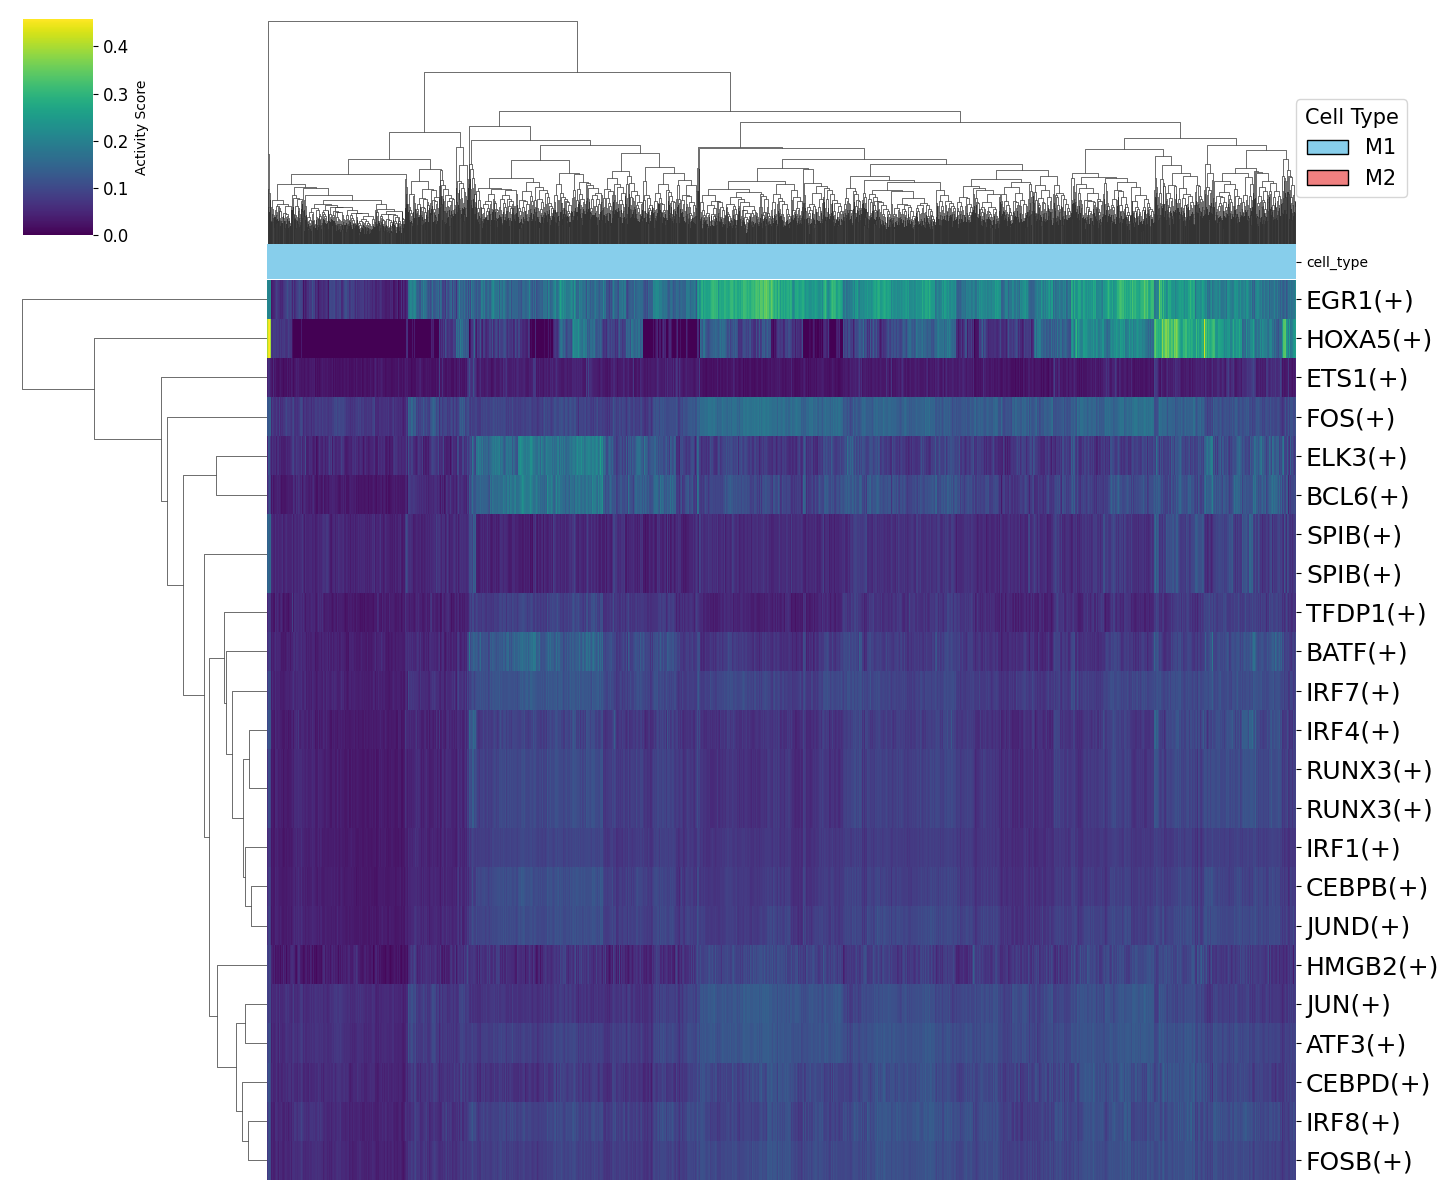

In [280]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 'cell_type'을 기준으로 정렬
df_sorted = df_filtered.sort_values(by='cell_type')

# 히트맵 데이터에서 'Cell'과 'cell_type' 열 제거
heatmap_data = df_sorted.drop(columns=['Cell', 'cell_type'])

# 셀 타입에 따른 색상 지정
cell_type_colors = df_sorted['cell_type'].map({'M1': 'skyblue', 'M2': 'lightcoral'})

# clustermap 생성
g = sns.clustermap(
    heatmap_data.T,
    col_colors=cell_type_colors,
    cmap='viridis',
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 12),
    cbar_kws={'label': 'Activity Score'},
)

# 오른쪽에 범례 추가
handles = [
    Patch(facecolor='skyblue', edgecolor='black', label='M1'),
    Patch(facecolor='lightcoral', edgecolor='black', label='M2')
]


# y축 라벨 (gene 이름 등) 글자 크기 키우기
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=18)

# x축 라벨 (cell 이름 등) 글자 크기 키우기
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=12)

# colorbar 폰트 크기 키우기
g.cax.tick_params(labelsize=12)

# 범례 타이틀과 항목 폰트 크기 키우기
g.ax_heatmap.legend(
    handles=handles,
    title='Cell Type',
    title_fontsize=15,     # 범례 제목 글자 크기
    loc='upper left',
    bbox_to_anchor=(1.00, 1.2),
    borderaxespad=0.,
    fontsize=15            # 범례 항목 글자 크기
)

plt.show()


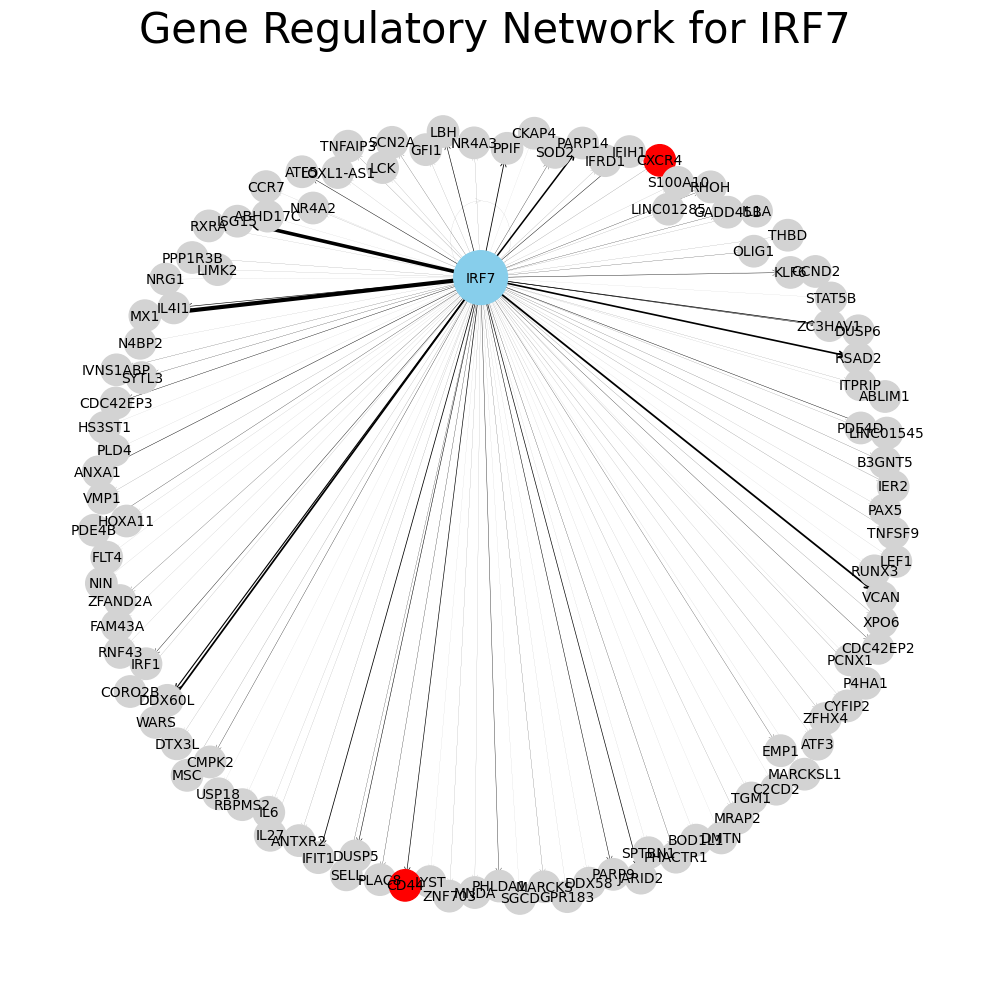

In [288]:
import networkx as nx
import matplotlib.pyplot as plt

# IRF7와 관련된 TargetGenes 목록
target_genes = [
    ('ZC3HAV1', 13.92493193718401), ('USP18', 0.6788725626969669), ('MX1', 82.96179476048633),
    ('IFRD1', 2.035246980373861), ('RXRA', 1.273927453735206), ('ATF3', 1.5455065675684871),
    ('DTX3L', 1.7695677860851262), ('LIMK2', 1.4747225979765743), ('DUSP5', 10.423335846381669),
    ('DDX58', 0.8855270354958946), ('IRF1', 7.968261212562736), ('NR4A3', 1.8973382166473012),
    ('PLD4', 0.8876192716218558), ('SGCD', 0.8243584999805165), ('PARP9', 10.037194696914945),
    ('CCR7', 1.0421633360449325), ('DUSP6', 8.701728657738402), ('IFIT1', 15.429218926331403),
    ('RUNX3', 0.7371338818317917), ('VMP1', 2.184909633469513), ('NRG1', 0.8918659497825655),
    ('ABHD17C', 0.7889003002452732), ('NR4A2', 1.6667809633961788), ('MARCKS', 3.093909082662728),
    ('ABLIM1', 1.115464791094816), ('THBD', 1.77097924052714), ('CKAP4', 0.673595178738684),
    ('WARS', 34.98873512613027), ('NIN', 0.9078846642454772), ('IL6', 1.3950371764320049),
    ('VCAN', 35.62520804825206), ('SYTL3', 4.35366015841934), ('ISG15', 71.57893478345581),
    ('TNFAIP3', 2.6430089358154105), ('MRAP2', 2.175518715903804), ('IVNS1ABP', 3.371182207574891),
    ('GADD45B', 4.639030126204988), ('DMTN', 0.710647495581183), ('IRF7', 1.0),
    ('MNDA', 1.5289586612119812), ('RSAD2', 33.16376790596919), ('ZNF703', 1.81735047104008),
    ('CMPK2', 5.905489433815234), ('KLF6', 7.19418463941239), ('TNFSF9', 2.724650691831199),
    ('N4BP2', 1.1318736364099182), ('ITPRIP', 1.945724326445589), ('PAX5', 1.4306208981192183),
    ('LINC01285', 1.814634233901692), ('MSC', 2.3552722019902776), ('HS3ST1', 0.8536455228527873),
    ('HOXA11', 1.2519947467363324), ('XPO6', 2.745332166295352), ('GFI1', 1.8315935268044987),
    ('IL27', 1.5481070147096914), ('RBPMS2', 0.8814165272011139), ('CCND2', 1.3264845560108742),
    ('PARP14', 30.73064168609833), ('C2CD2', 0.8713117495971346), ('IER2', 3.0697182106649112),
    ('CXCR4', 2.6133076061243887), ('PLAC8', 5.241246906609376), ('ZFAND2A', 3.9093570827371),
    ('RHOH', 5.394025577135935), ('PDE4B', 5.346543604906951), ('LYST', 0.7671359721108634),
    ('FAM43A', 1.164706835744101), ('LEF1', 1.021892644171836), ('PPIF', 16.360810616495836),
    ('LBH', 11.80602963711194), ('CDC42EP2', 5.67205273169099), ('EMP1', 4.494238897034124),
    ('SELL', 4.3374501596328185), ('PDE4D', 2.266447934197759), ('RNF43', 1.2439029808319957),
    ('CYFIP2', 1.426175822754827), ('FLT4', 0.9009686904665553), ('P4HA1', 2.7021253897901163),
    ('S100A10', 1.3987595997953992), ('LOXL1-AS1', 1.3622023879830778), ('LCK', 1.803100216049072),
    ('OLIG1', 3.902172754276409), ('PPP1R3B', 1.9802758878354347), ('ANTXR2', 2.154774339296029),
    ('ANXA1', 8.78847111180423), ('JARID2', 13.101967216455868), ('PHLDA1', 7.271573525670973),
    ('BOD1L1', 0.9865388383875012), ('PCNX1', 0.9015471365668052), ('MARCKSL1', 0.8526097934661174),
    ('CD44', 12.899897963511554), ('IL1A', 1.827582558814981), ('IL4I1', 12.063256027974246),
    ('B3GNT5', 3.27696852199346), ('SPTBN1', 0.9629910661863208), ('ATF5', 9.26150238994368),
    ('LINC01545', 8.469496084120662), ('DDX60L', 22.635335192571304), ('IFIH1', 8.881971803164587),
    ('STAT5B', 0.7435205966520197), ('PHACTR1', 4.4724137699949535), ('SCN2A', 3.7028669263518186),
    ('GPR183', 0.9682115618497064), ('CDC42EP3', 7.7812907245890575), ('CORO2B', 1.723699499881207),
    ('SOD2', 5.847146969527639), ('TGM1', 1.214370599017885), ('ZFHX4', 2.549257774432484)
]

# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('IRF7', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=10, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'IRF7' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'IRF7' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'IRF7' else
    'red' if node in ['CD44', 'CXCR4'] else
    'blue' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(10, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=10)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for IRF7", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


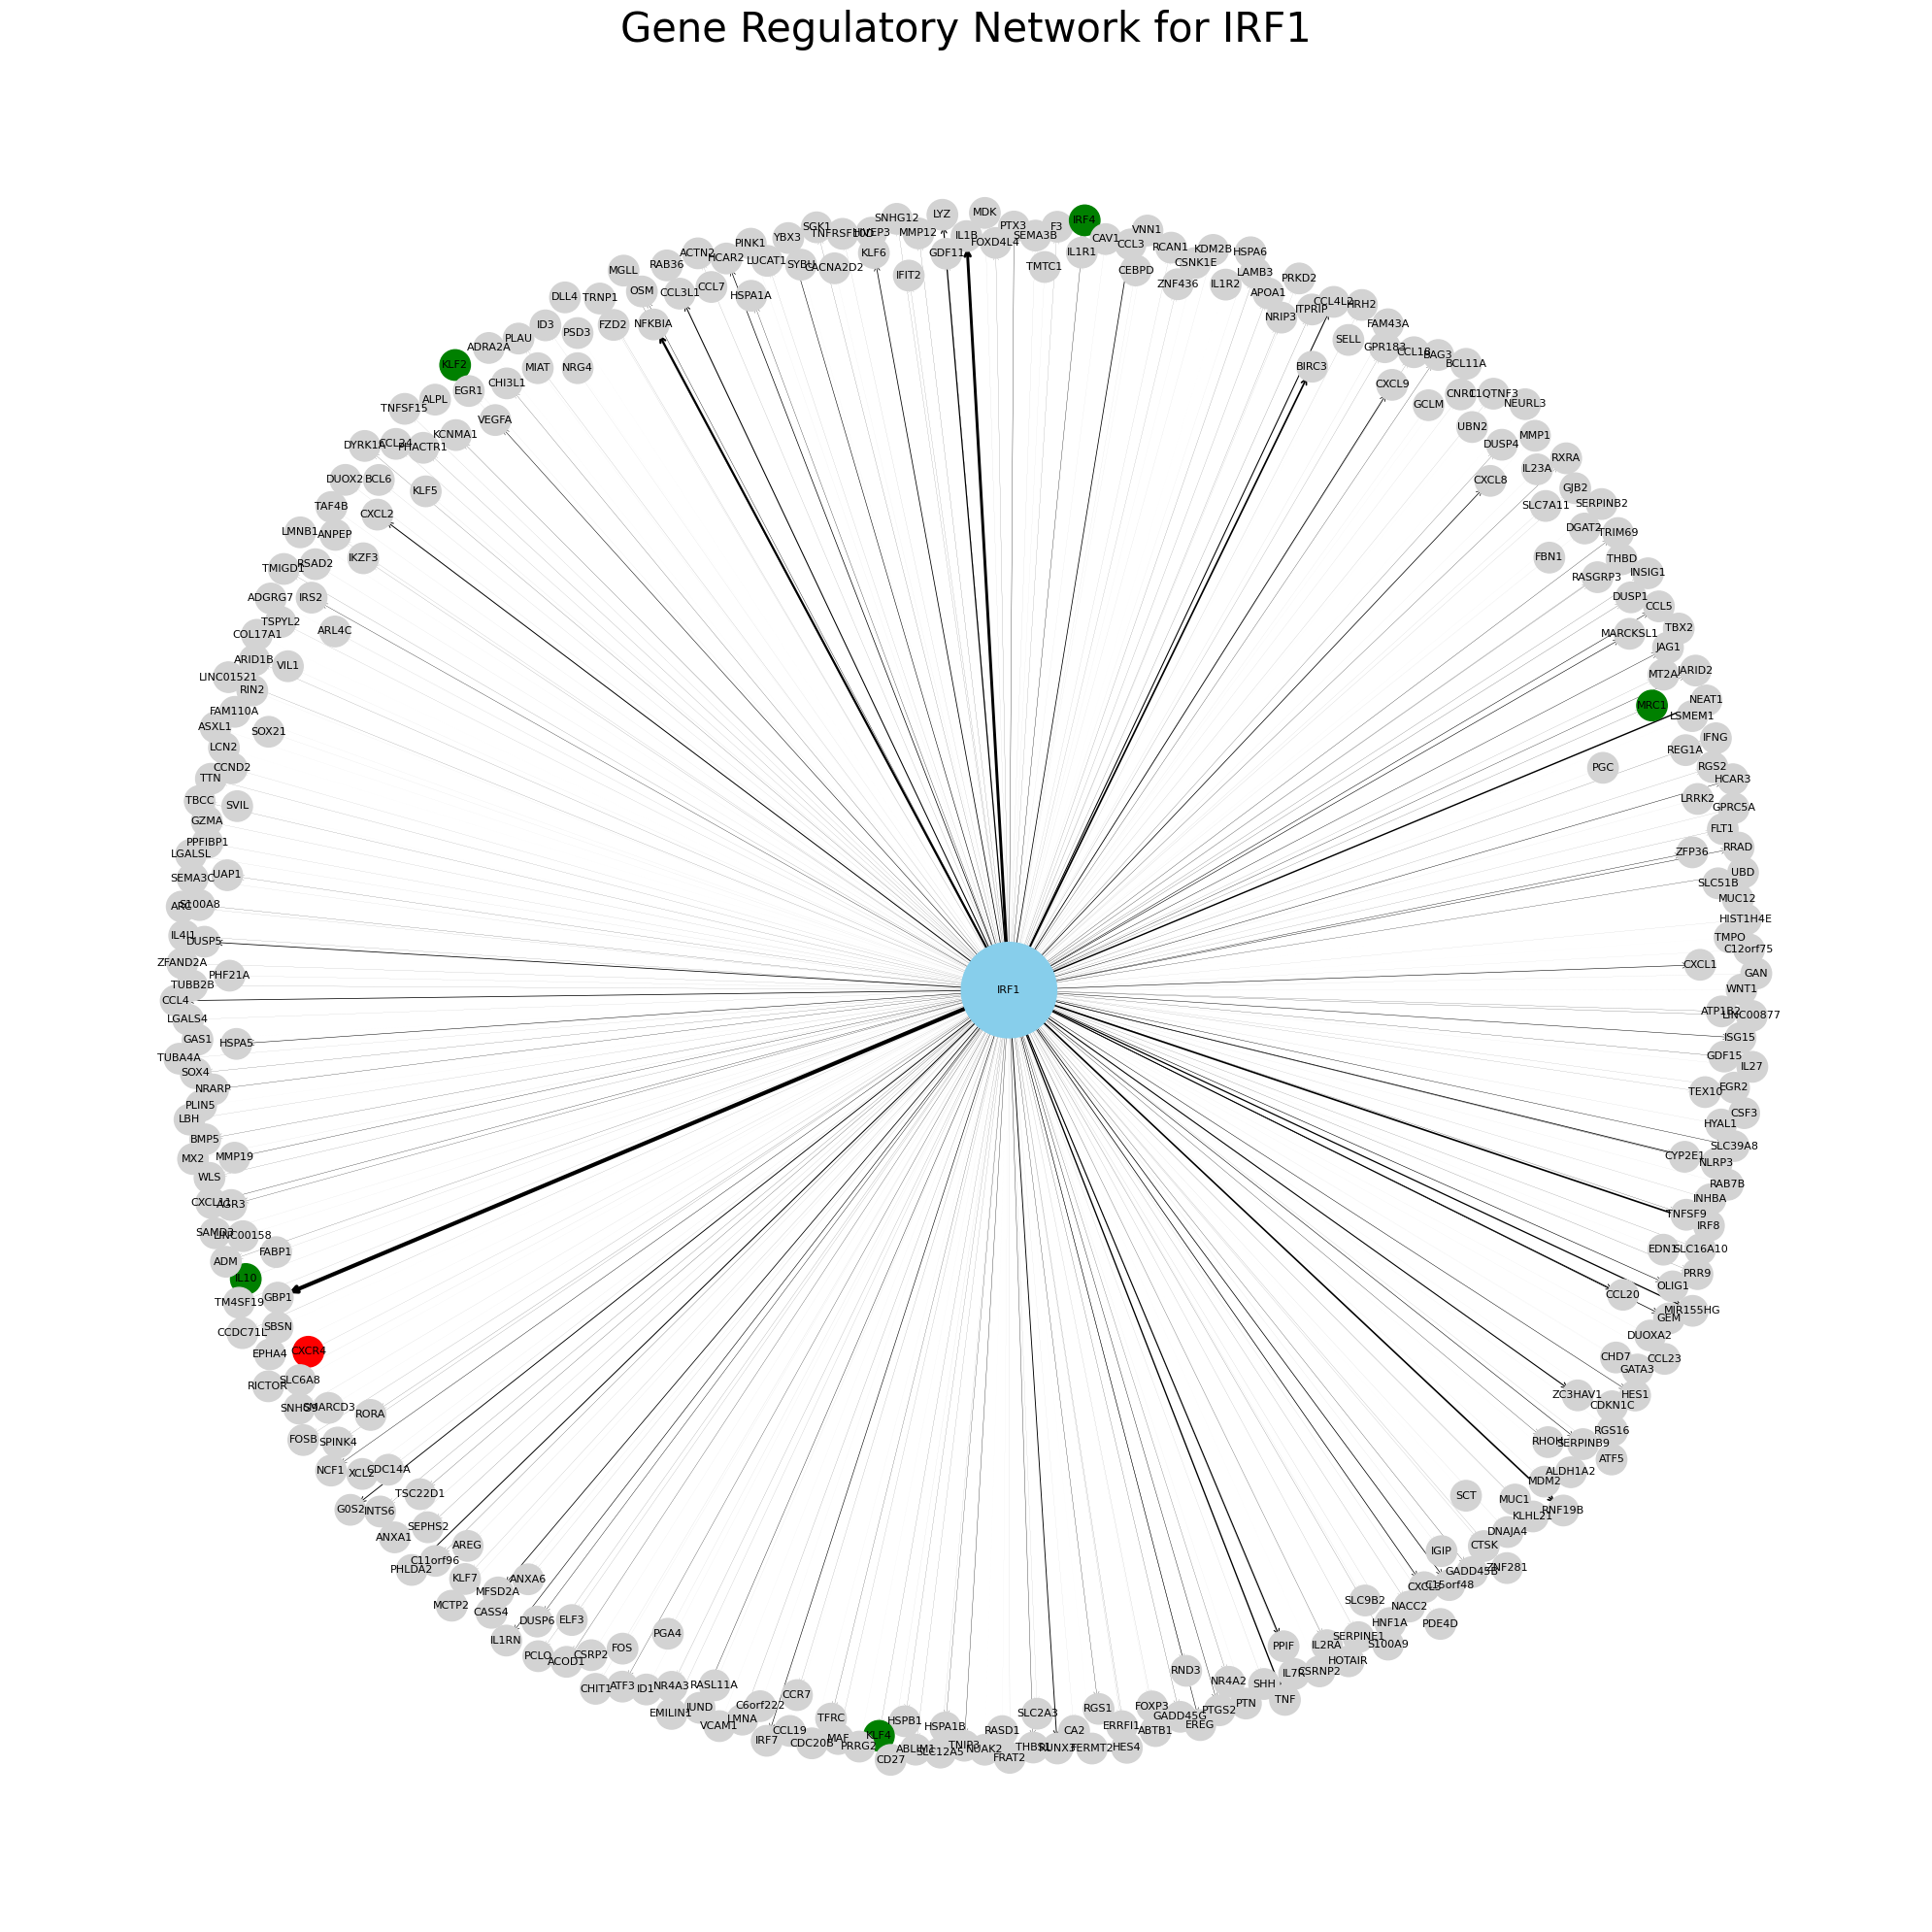

In [293]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'IRF1']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('IRF1', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'IRF1' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [5000 if node == 'IRF1' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'IRF1' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(20, 20))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for IRF1", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


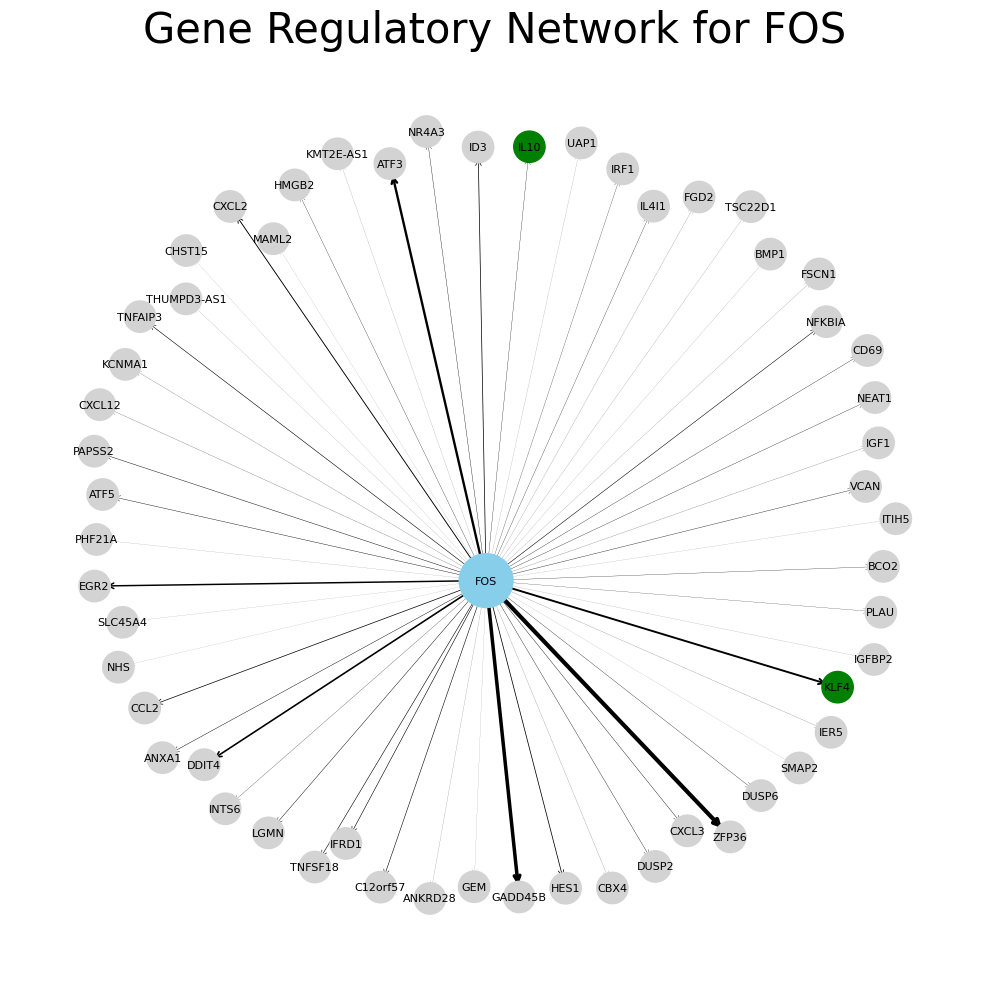

In [300]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'FOS']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('FOS', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'FOS' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'FOS' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'FOS' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(10, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for FOS", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


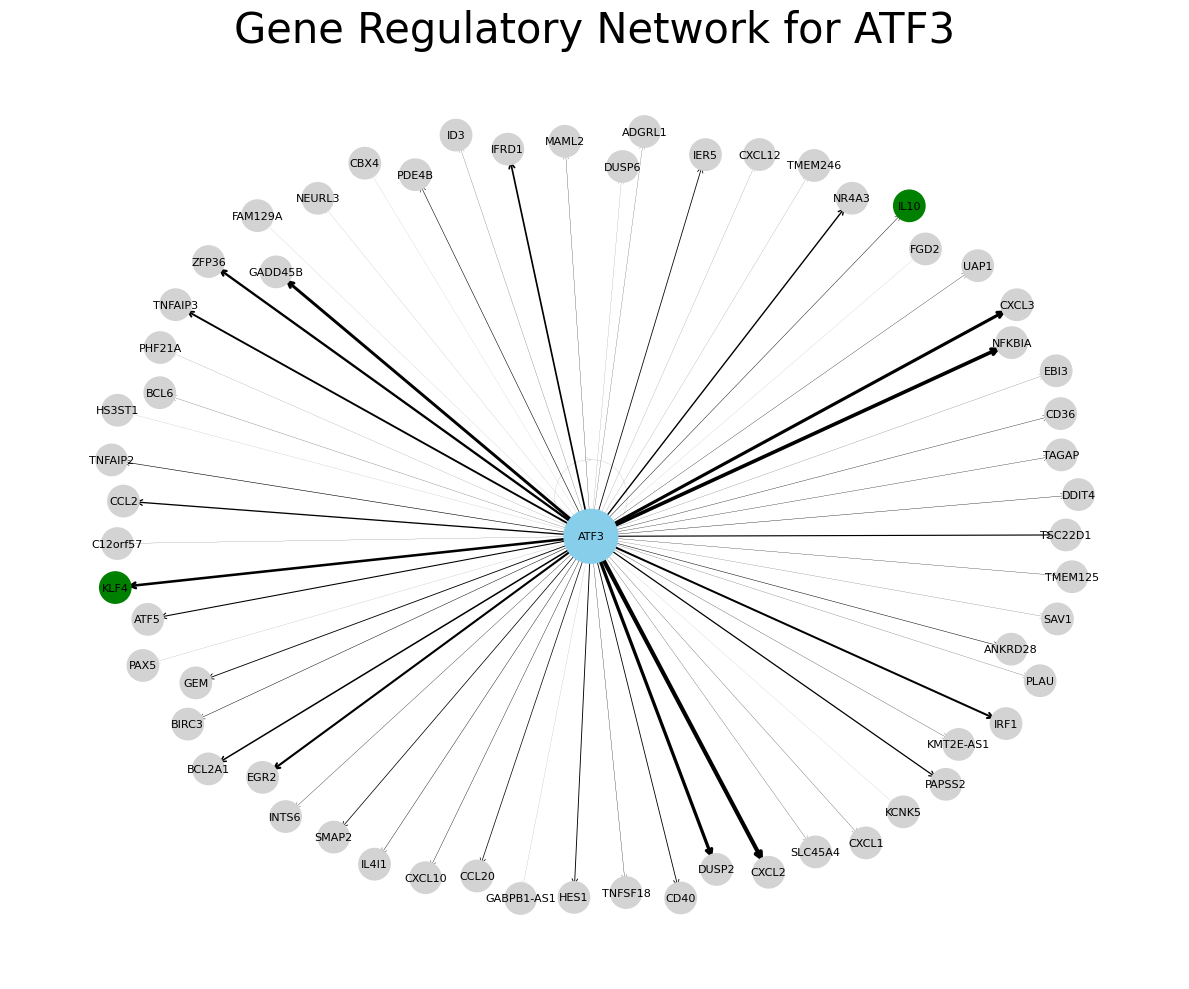

In [295]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'ATF3']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('ATF3', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'ATF3' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'ATF3' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'ATF3' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(12, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for ATF3", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


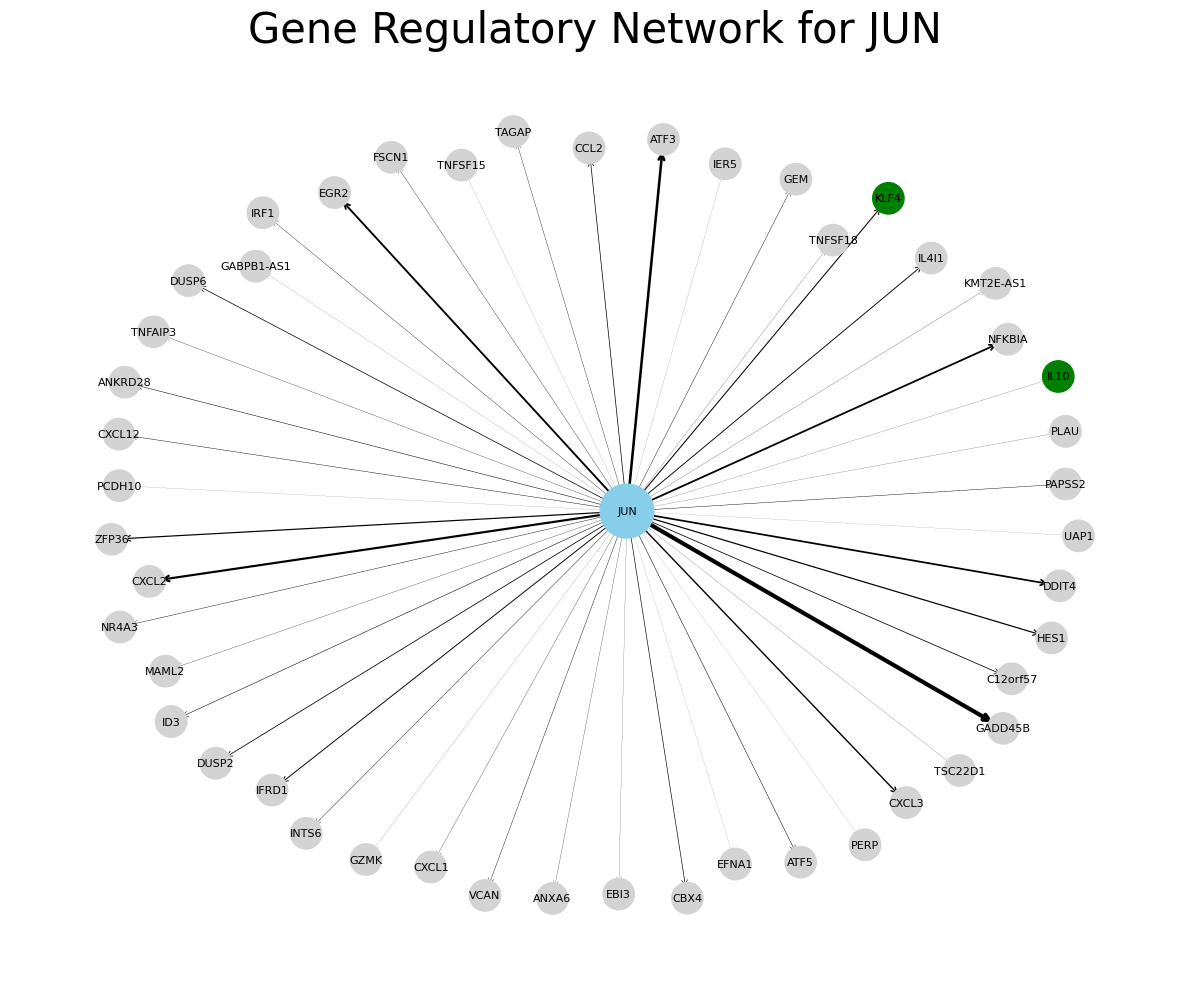

In [296]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'JUN']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('JUN', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'JUN' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'JUN' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'JUN' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(12, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for JUN", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


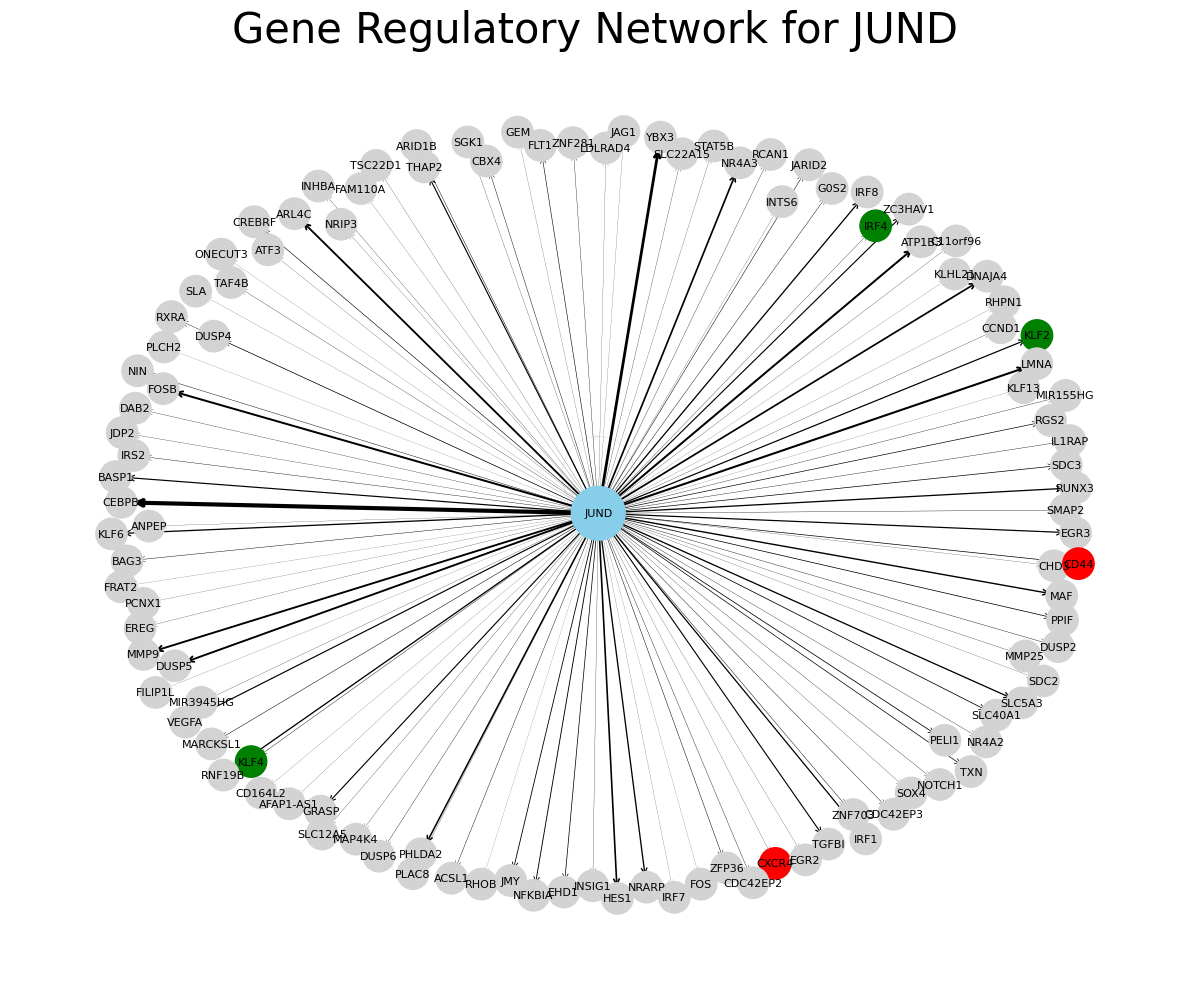

In [297]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'JUND']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('JUND', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'JUND' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'JUND' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'JUND' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(12, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for JUND", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


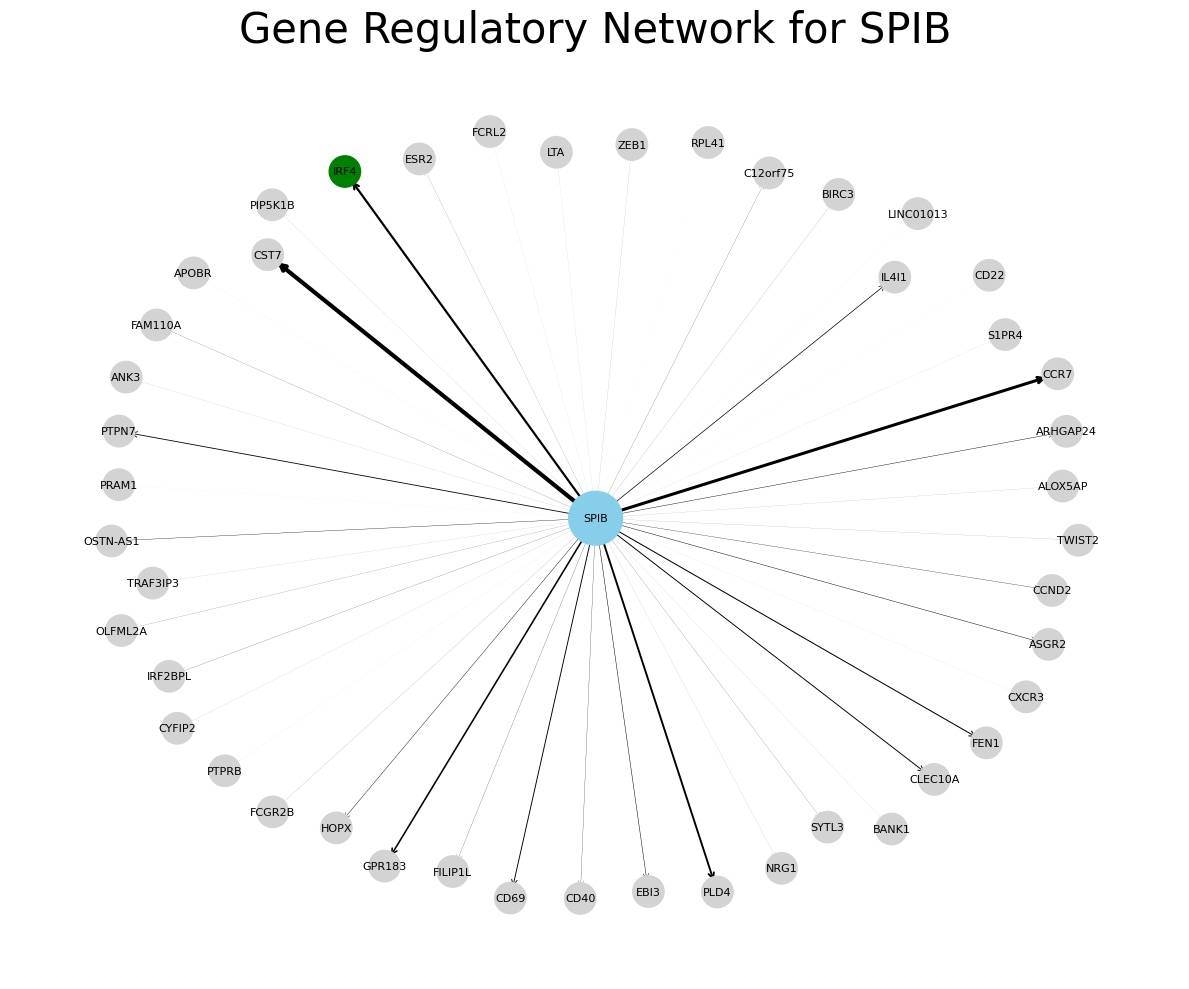

In [298]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'SPIB']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('SPIB', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'SPIB' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'SPIB' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'SPIB' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(12, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for SPIB", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()


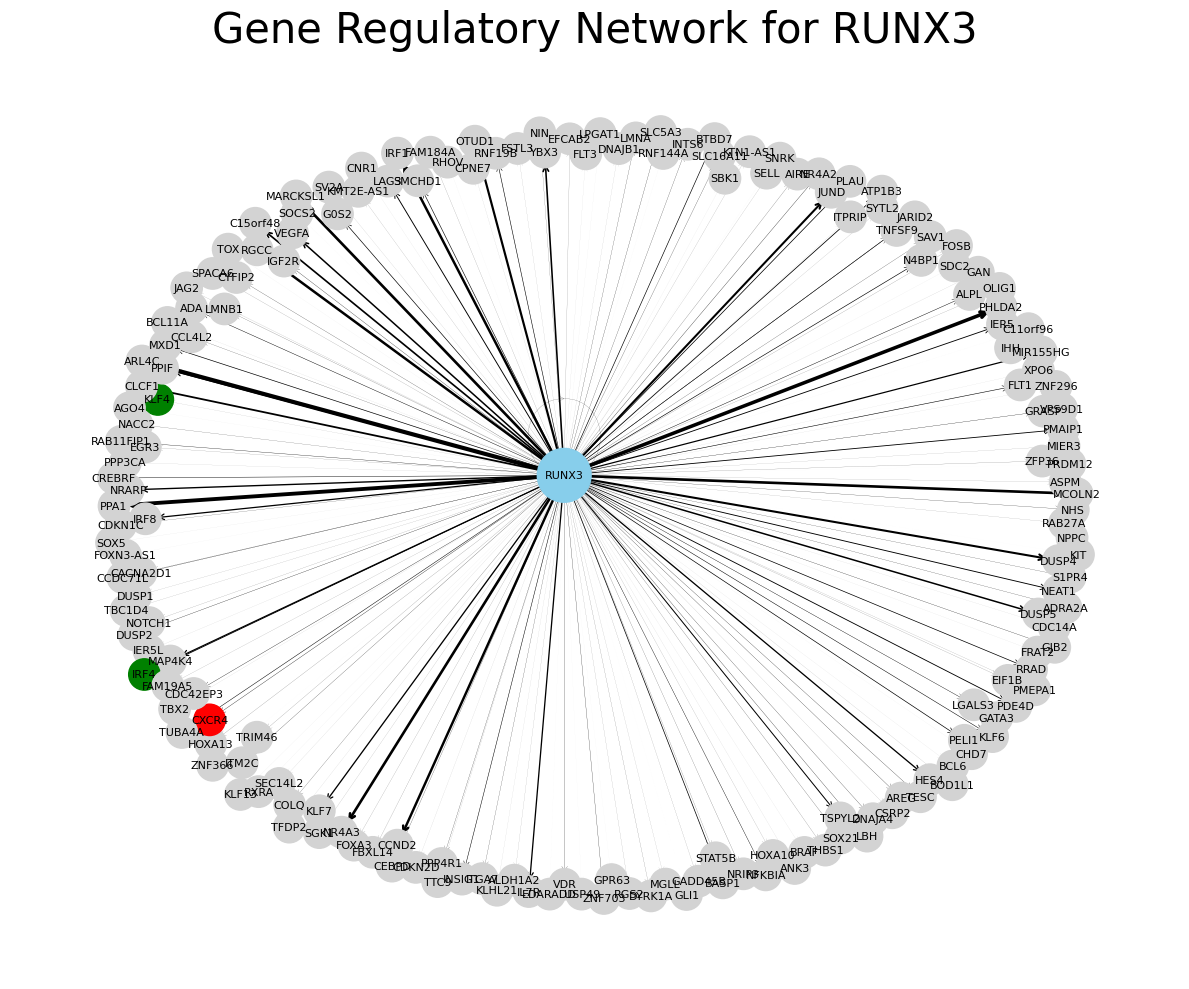

In [299]:
import networkx as nx
import matplotlib.pyplot as plt

target_gene_str = df_regulons[df_regulons['TF'] == 'RUNX3']['TargetGenes'].values[0]
target_genes = ast.literal_eval(target_gene_str)
# 네트워크 초기화
G = nx.DiGraph()

# 'IRF7'과 관련된 TargetGenes을 추가
for gene, score in target_genes:
    if score > 0:  # co-relation score가 0보다 큰 경우만 추가
        G.add_edge('RUNX3', gene, weight=score)  # IRF7에서 gene으로 가는 엣지를 추가

# 레이아웃 설정 (네트워크의 위치 설정)
pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

# 노드 색상 설정 (TF는 파랑, 타겟은 회색)
node_colors = ['skyblue' if node == 'RUNX3' else 'lightgray' for node in G.nodes]

# 노드 크기 설정 (IRF7만 크게 설정)
node_sizes = [1500 if node == 'RUNX3' else 10 + G.degree(node) * 500 for node in G.nodes]

# 엣지 두께 (score 기반으로 엣지의 두께 결정)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights) if edge_weights else 1  # 최대 weight 값 구하기
edge_widths = [w / max_weight * 3 for w in edge_weights]  # 두께 비율로 설정
# 노드 색상 설정 (IRF7은 파랑, CD44와 CXCR4는 빨강, 나머지는 회색)
node_colors = [
    'skyblue' if node == 'RUNX3' else
    'red' if node in ['CD44', 'CXCR4'] else
    'green' if node in ['ARG1','ARG2','NOS2','SCARB1','ALOX15','MRC1','SOCS1','KLF4','Fizz1','KLF2','KLF4','IL10','IL4',	'KLF4',	'IRF4',	'SOCS1'
] else
    'lightgray'
    for node in G.nodes
]

# 시각화
plt.figure(figsize=(12, 10))  # 그래프 크기 설정
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0)  # 노드 그리기
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1.0, arrows=True, arrowstyle='->')  # 엣지 그리기
nx.draw_networkx_labels(G, pos, font_size=8)  # 노드에 라벨 표시

# 제목 추가
plt.title(f"Gene Regulatory Network for RUNX3", fontsize=30)
plt.axis('off')  # 축 숨기기
plt.tight_layout()  # 레이아웃 조정
plt.show()
